# Spatial and Metallicity Distributions
This notebok showcases the code used to create the spatial
and metallicity distributions used in my poster for the
UURIP24 poster event.

Full credit to Lusimi for the classes and functions used
in "functions". For more visit:
https://github.com/luismi98/astrophysics-research

## Spatial Distribution
This segement show the code used to plot the APOGEE and RR Lyrae stars in galactic coordinates

############################################## Read in data ############################################## 


Load RRLyr
Removed 1130 bad indices, leaving 6077 stars.


Load APOGEE
Found 13031 total stars.
Removed 2545 bad indices, leaving 10486 stars.
############################################## Spatial Cuts ############################################## 


[]

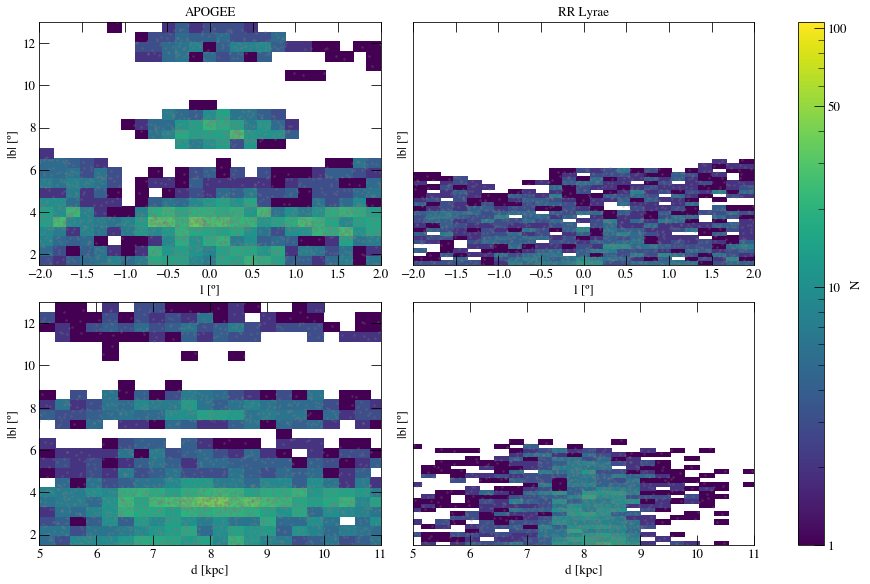

In [13]:
### BMcD 11/09/2024 - code to show the spatial distribution of APOGEE and RR Lyrae stars for the poster event (UURIP24)
###                   The code takes the neccessary spatial cuts in galactic coordinates: 1.5º<|b|<13º, |l|<2º, R_sun<3.5 
###                   and plots the stars in l-b and d-b space, the plots are colour code by the number of stars

############################################## Libraries ############################################## 

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import functions.compute_variables as CV
from functions.errorconfig import BootstrapConfig
import functions.montecarlo_errors as montecarlo
import functions.bootstrap_errors as bootstrap

import functions.matplotlib_param_funcs as plot_param

import functions.load_data as load_data
import functions.load_RRLyr as load_RRLyr

plot_param.set_matplotlib_params()

############################################## Functions ############################################## 

def spatial_plot(x, y, row, col, x_cut, y_cut, x_label, y_label, min, max):
    """
    Parameters
    ----------
    x, y: The x and y data to subplot
    row, col: The row and column to subplot 
    xcut, ycut: cuts on the subplot 
    xlabel, ylabel: x and y axe labels for the subplot
    min, max: minimum and maximum number of stars in the subplot

    Returns
    ---------
    A subplot at [row, col] of the spatial distribution
    """
        
    global norm ### need to apply norm to the colour bar

    # binning for no. stars
    count, x_edge, y_edge = np.histogram2d(x, y, bins=25)

    count = count.T

    # get centre of each bin
    x_width = (x_edge[1] - x_edge[0])
    x_center = x_edge[1:] - x_width/2

    y_width = (y_edge[1] - y_edge[0])
    y_center = y_edge[1:] - y_width/2

    norm=LogNorm(min, max)

    ax[row, col].pcolor(x_center, y_center, count, cmap='viridis', norm=norm)
    ax[row, col].scatter(x, y, s=3, c='grey', alpha=0.2)

    ax[row, col].set(xlim=x_cut, ylim=y_cut, xlabel=x_label, ylabel=y_label)  


# Finds the min and max number of stars in the param space (say l-b space) 
def min_max_pop(data, param):

    """
    Parameters
    ----------
    param: a list of x and y axes e.g. [['l', 'b'], ['d', 'b'], ['x', 'y']]
    data: pandas dataframe containing the x and y parameters used to create the plot

    Returns
    ---------
    vmin: lowest number of stars across the param space
    vmax: highest number of stars across the param space
    """

    vmin=0; vmax=0

    for axes in param:
        count, _, _, = np.histogram2d(data[axes[0]], data[axes[1]], bins=13)

        count = count.T

        if count.min()<vmin:
            vmin = count.min()
        if count.max()>vmax:
            vmax = count.max()

    return vmin, vmax


R0 = 8.1
Z0 = 0
obs_errors = False
GSR=True
zabs = True 

############################################## Read in data ############################################## 

print('############################################## Read in data ############################################## ')

print('\n')

print('Load RRLyr')
RRLyr_data = load_RRLyr.load_RRLyr_data('../data/RRLyr-6D.csv')
print('\n')
print('Load APOGEE')
APOGEE_d = load_data.load_and_process_data(data_path='../../data/observations/', error_bool=obs_errors, zabs=zabs, R0=R0, GSR=GSR)

############################################## Spatial Cuts ############################################## 

print('############################################## Spatial Cuts ############################################## ')

# set spatial cuts 
x_variable = "l"
y_variable = "b"

extra_variable = "R"

xmin = -2
xmax = 2

ymin = 1.5
ymax = 13

dmin=5
dmax=11

extra_min = 0
extra_max = 3.5

xymax = 3.5
zmax = 3

# metallciity cuts - takes RR Lyrae stars of [Fe/H]=[-2.5, -1] and APOGEEstars of [Fe/H]=[-1.5, inf)

RRLyr_spatial = RRLyr_data[(RRLyr_data[x_variable]>=xmin)&(RRLyr_data[x_variable]<=xmax)&(RRLyr_data[y_variable]>=ymin)&(RRLyr_data[y_variable]<=ymax)&(RRLyr_data[extra_variable]>=extra_min)&(RRLyr_data[extra_variable]<extra_max)&(-2.5<=RRLyr_data['FeH'])&(RRLyr_data['FeH']<=-1)]

APOGEE_spatial = APOGEE_d[(APOGEE_d[x_variable]>=xmin)&(APOGEE_d[x_variable]<=xmax)&(APOGEE_d[y_variable]>=ymin)&(APOGEE_d[y_variable]<=ymax)&(APOGEE_d[extra_variable]>=extra_min)&(APOGEE_d[extra_variable]<extra_max)&(-1.5<=APOGEE_d['FeH'])]

############################################## PLotting ############################################## 


# cuts to be used in plotting
spatial_cut_dict = {

    'b': (1.5, 13),
    'l': (-2, 2),
    'd': (5, 11),
    'x': (-3.6, 3.6),
    'y': (-2, 2),
    'z': (-0.05, 2.5)

}

# labels for plotting
label_dict = {

    'l': r'l [º]',
    'b': '|b| [º]',
    'd': r'd [kpc]'
}

# list of datasets to loop through
data = [APOGEE_spatial, RRLyr_spatial]

# axes to plot
axes_point = [ ['l', 'b'], ['d', 'b']]#, ['x', 'y'] ]

fig, ax = plt.subplots(len(axes_point), len(data), constrained_layout=True)

# checks both datasets for the min and max number of stars
vmin, vmax = min_max_pop(RRLyr_spatial, axes_point)
vmin, vmax = min_max_pop(APOGEE_spatial, axes_point)

# cannot show "no" stars so set min to one
if vmin == 0:
    vmin=1

for row, axes in enumerate(axes_point):
    for col, d_set in enumerate(data):

        x_axes = axes[0]
        y_axes = axes[1]

        pm = spatial_plot(x=d_set[x_axes], y=d_set[y_axes], row=row, col=col, x_cut=spatial_cut_dict[x_axes], y_cut=spatial_cut_dict[y_axes], x_label=label_dict[x_axes], y_label=label_dict[y_axes], min=vmin, max=vmax)

# colour bar
cbar = fig.colorbar(pm, ax=ax, norm=norm, label='N')
cbar.ax.set_yticks([1, 10, 50, 100])
cbar.ax.set_yticklabels([1, 10, 50, 100])

# plotting cosemtics 
ax[0, 0].set_title('APOGEE')
ax[0, 1].set_title('RR Lyrae')

ax[0, 1].set_yticks([])
ax[1, 1].set_yticks([])

#plt.show()
#plt.savefig('plots/spatial_distribution/APOGEE_RRLyrae.pdf')

## Metallicity Distribution
This segement shows the code to create the metallicity histograms for the APOGEE and RR Lyrae data

############################################## Read in data ############################################## 


Load RRLyr
Removed 1130 bad indices, leaving 6077 stars.


Load APOGEE
Found 13031 total stars.
Removed 2545 bad indices, leaving 10486 stars.
############################################## Spatial Cuts ############################################## 


############################################## PLotting ############################################## 


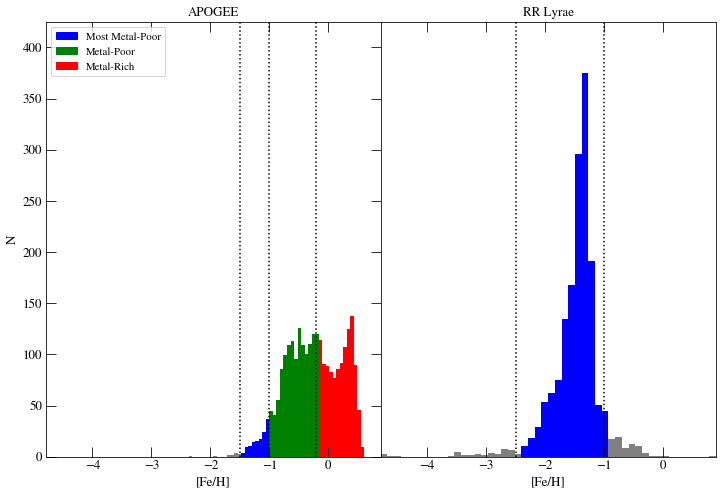

In [12]:
### BMcD 11/09/2024 - histogram plots of the metallicity distribution of APOGEE and RR Lyrae stars 
###                   These plots help visualise the metallicity populations used


import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm

import functions.miscellaneous_functions as MF
import functions.matplotlib_param_funcs as plot_param

import functions.load_data as load_data
import functions.load_RRLyr as load_RRLyr

plot_param.set_matplotlib_params()
    
R0 = 8.1
Z0 = 0
obs_errors = False
GSR=True
zabs = True 

############################################## Read in data ############################################## 

print('############################################## Read in data ############################################## ')

print('\n')

print('Load RRLyr')
RRLyr_data = load_RRLyr.load_RRLyr_data('../data/RRLyr-6D.csv')
print('\n')
print('Load APOGEE')
APOGEE_d = load_data.load_and_process_data(data_path='../../data/observations/', error_bool=obs_errors, zabs=zabs, R0=R0, GSR=GSR)

############################################## Spatial Cuts ############################################## 

print('############################################## Spatial Cuts ############################################## ')

# set spatial cuts 
x_variable = "l"
y_variable = "b"

extra_variable = "R"

xmin = -2
xmax = 2

ymin = 1.5
ymax = 13

dmin=5
dmax=11

extra_min = 0
extra_max = 3.5

xymax = 3.5
zmax = 3

RRLyr_spatial = RRLyr_data[(RRLyr_data[x_variable]>=xmin)&(RRLyr_data[x_variable]<=xmax)&(RRLyr_data[y_variable]>=ymin)&(RRLyr_data[y_variable]<=ymax)&(RRLyr_data[extra_variable]>=extra_min)&(RRLyr_data[extra_variable]<extra_max)]
APOGEE_spatial = APOGEE_d[(APOGEE_d[x_variable]>=xmin)&(APOGEE_d[x_variable]<=xmax)&(APOGEE_d[y_variable]>=ymin)&(APOGEE_d[y_variable]<=ymax)&(APOGEE_d[extra_variable]>=extra_min)&(APOGEE_d[extra_variable]<extra_max)]

print("\n")

############################################## PLotting ############################################## 

print('############################################## PLotting ############################################## ')

fig, ax = plt.subplots(ncols=2)

bins=50

# start with the APOGEE data
luismi_data = APOGEE_spatial[-1<=APOGEE_spatial['FeH']] ### limit set by Lusimi, see San Martin Fernandes et al. (2024)  

# Find number of stars for a histogram plot
APOGEE_count, APOGEE_edge, APOGEE_patch = ax[0].hist(APOGEE_spatial['FeH'], bins=bins)

# assign colours for different metallicity populations
labels = ['Most Metal-poor', 'Metal-poor', 'Metal-Rich']
colours = ['blue', 'green', 'red']

# colour in each bin according to their metallicity population - if outside the metallicity cuts colour the bins grey
# (there is a caveat here, the bin edges will not exactly align with the population edges - this is only a visual issue and does not affect the anlysis)
for edges, p in zip(APOGEE_edge, APOGEE_patch):
    if -1.5<=edges<=-1: 
        colour='blue'
        label='Most Metal-poor'

    elif -1<=edges<=np.median(luismi_data['FeH']):
        colour='green'
        label='Metal-poor'

    elif np.median(luismi_data['FeH'])<=edges<=np.max(APOGEE_spatial['FeH']):
        colour='red'
        label='Metal-Rich'

    else:
        colour='grey'

    p.set_facecolor(colour)

# labels for the legend
most_mp=mpatches.Patch(color='blue', label='Most Metal-Poor')
mp = mpatches.Patch(color='green', label='Metal-Poor')
mr = mpatches.Patch(color='red', label='Metal-Rich') 
ax[0].legend(handles=[most_mp, mp, mr])

# dotted lines to help visualise the metallciity populations
ax[0].axvline(-1, ls=':', c='k')
ax[0].axvline(-1.5, ls=':', c='k')
ax[0].axvline(np.median(luismi_data['FeH']), ls=':', c='k')
ax[0].set(xlabel='[Fe/H]', ylabel='N', title='APOGEE')

# do the same with the RR Lyrae data
rrlyr_count , rrlyr_bin_edges, rrlyr_patches = ax[1].hist(RRLyr_spatial['FeH'], bins=bins)

for edges, p in zip(rrlyr_bin_edges, rrlyr_patches):
    if -2.5<=edges<=-1: 
        colour='blue' 
    else:
        colour='grey'

    p.set_facecolor(colour)

ax[1].axvline(-1, ls=':', c='k')
ax[1].axvline(-2.5, ls=':', c='k')
ax[1].set(title='RR Lyrae', yticks=[], xlabel='[Fe/H]')

# plotting cosemtics 
plt.setp(ax, ylim=(0, rrlyr_count.max()+50), xlim=(RRLyr_spatial['FeH'].min(), RRLyr_spatial['FeH'].max()))
fig.subplots_adjust(wspace=0)

#plt.savefig('plots/feh_distribution/APOGEE_RRLyr_seperate_better_egdes.pdf')
plt.show()
